# Fraud Analytics - EDA, Feature Engineering, and Modeling

1.85M simulated card transactions (2019-2020) loaded into PostgreSQL; this
notebook asks where fraud hides, engineers the customer→merchant distance
feature, and trains a classifier evaluated the honest way (time-based split,
precision/recall). Data is **simulated** (Sparkov) - patterns are realistic,
people are not real.

Heavy counting happens **in SQL** (the database's job); pandas holds only
aggregates, samples, and the final modeling frame.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv

load_dotenv(r'C:\Projects\fraud-analytics\.env')
conn = psycopg2.connect(os.getenv('DATABASE_URL'))

def q(sql):
    return pd.read_sql(sql, conn)

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
print('connected')

connected


## 1. How rare is fraud?

The single most important number in the project - it decides how the model
must be evaluated.

In [2]:
tot = q('SELECT COUNT(*) AS n, SUM(is_fraud) AS fraud FROM transactions')
n, fraud = int(tot.n[0]), int(tot.fraud[0])
rate = fraud / n
print(f'{n:,} transactions | {fraud:,} fraud | fraud rate {rate:.3%}')
print(f'A model that never flags anything is {1 - rate:.3%} accurate - which is why accuracy is useless here.')

1,852,394 transactions | 9,651 fraud | fraud rate 0.521%
A model that never flags anything is 99.479% accurate - which is why accuracy is useless here.


## 2. Where does fraud cluster?

By spending category, and by hour of day.

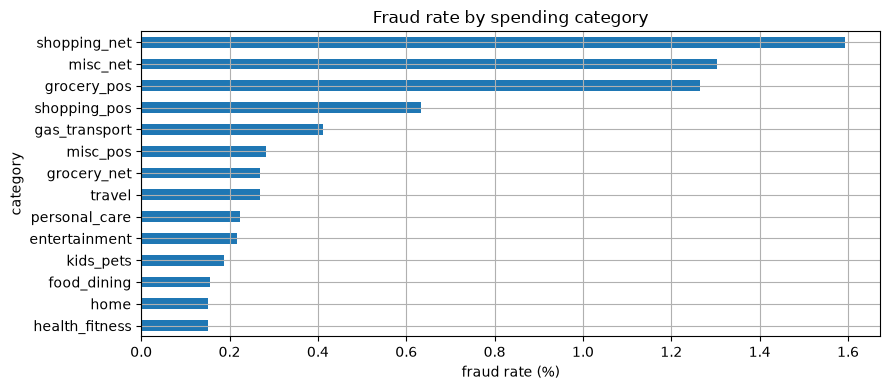

Highest-risk categories:
    category  fraud_pct
shopping_net       1.59
    misc_net       1.30
 grocery_pos       1.26


In [3]:
cat = q('SELECT category, COUNT(*) AS n, AVG(is_fraud) * 100 AS fraud_pct '
        'FROM transactions GROUP BY category ORDER BY fraud_pct')
ax = cat.set_index('category')['fraud_pct'].plot.barh()
ax.set_xlabel('fraud rate (%)')
ax.set_title('Fraud rate by spending category')
plt.tight_layout(); plt.show()
top = cat.sort_values('fraud_pct', ascending=False).head(3)
print('Highest-risk categories:')
print(top[['category', 'fraud_pct']].round(2).to_string(index=False))

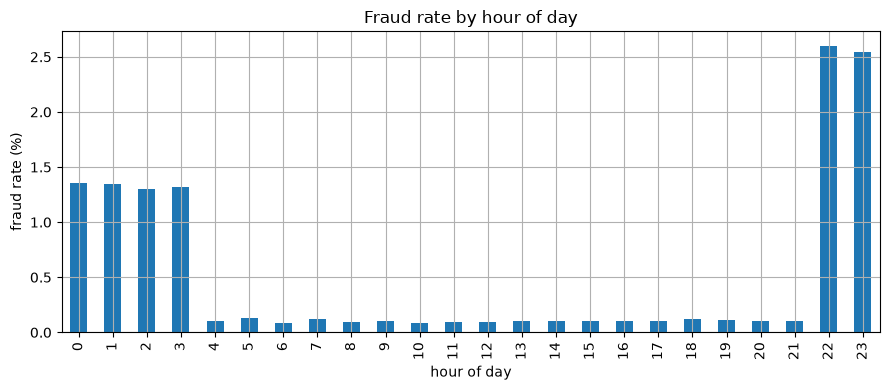

Night hours (22:00-03:59) average 1.75% fraud vs 0.10% in daytime - 16.7x higher.


In [4]:
hr = q('SELECT trans_hour, AVG(is_fraud) * 100 AS fraud_pct '
       'FROM transactions GROUP BY trans_hour ORDER BY trans_hour')
ax = hr.set_index('trans_hour')['fraud_pct'].plot.bar()
ax.set_xlabel('hour of day')
ax.set_ylabel('fraud rate (%)')
ax.set_title('Fraud rate by hour of day')
plt.tight_layout(); plt.show()
night = hr[hr.trans_hour.isin([22, 23, 0, 1, 2, 3])].fraud_pct.mean()
day = hr[~hr.trans_hour.isin([22, 23, 0, 1, 2, 3])].fraud_pct.mean()
print(f'Night hours (22:00-03:59) average {night:.2f}% fraud vs {day:.2f}% in daytime - {night/day:.1f}x higher.')

## 3. Do fraud amounts look different?

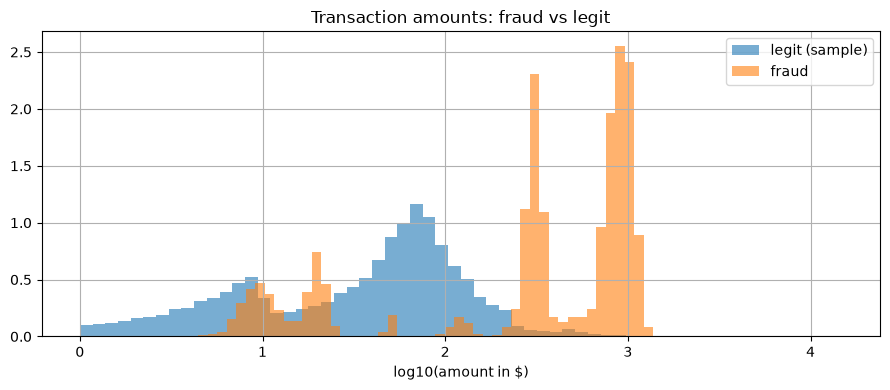

Median legit: $47.67   Median fraud: $390.00


In [5]:
fraud_amt = q('SELECT amt FROM transactions WHERE is_fraud = 1').amt.astype(float)
legit_amt = q('SELECT amt FROM transactions_raw TABLESAMPLE SYSTEM (3) '
              'WHERE is_fraud = 0 LIMIT 150000').amt.astype(float)
plt.hist(np.log10(legit_amt), bins=60, alpha=0.6, density=True, label='legit (sample)')
plt.hist(np.log10(fraud_amt), bins=60, alpha=0.6, density=True, label='fraud')
plt.xlabel('log10(amount in $)')
plt.title('Transaction amounts: fraud vs legit')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Median legit: ${legit_amt.median():.2f}   Median fraud: ${fraud_amt.median():.2f}')

## 4. The distance feature

Each row carries the customer's home coordinates **and** the merchant's.
Haversine distance between them is a candidate fraud signal: stolen card
details get used far from home. This cell also pulls the full modeling frame.

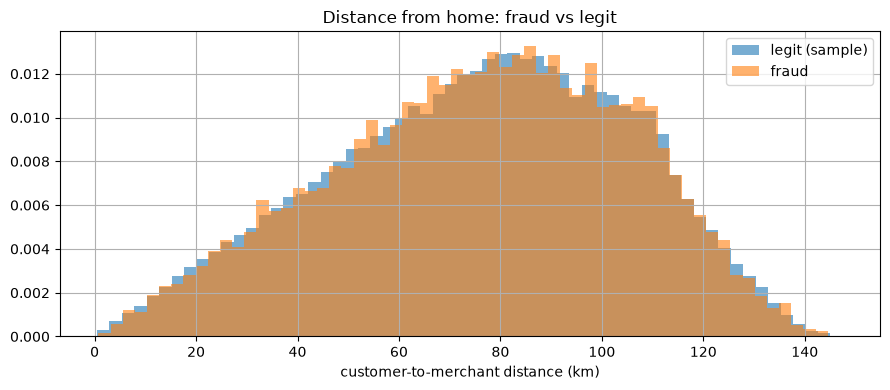

Median distance - legit: 78.2 km, fraud: 78.1 km


In [6]:
df = q('SELECT trans_time, category, amt, gender, customer_age, city_pop, '
       'cust_lat, cust_long, merch_lat, merch_long, is_fraud FROM transactions')
df['amt'] = df.amt.astype('float32')
df['is_fraud'] = df.is_fraud.astype('int8')

R = 6371.0  # earth radius, km
rad = np.pi / 180
la1 = df.cust_lat.values * rad
lo1 = df.cust_long.values * rad
la2 = df.merch_lat.values * rad
lo2 = df.merch_long.values * rad
a = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
df['distance_km'] = (2 * R * np.arcsin(np.sqrt(a))).astype('float32')

plt.hist(df.loc[df.is_fraud == 0, 'distance_km'].sample(150000, random_state=0),
         bins=60, alpha=0.6, density=True, label='legit (sample)')
plt.hist(df.loc[df.is_fraud == 1, 'distance_km'], bins=60, alpha=0.6, density=True, label='fraud')
plt.xlabel('customer-to-merchant distance (km)')
plt.title('Distance from home: fraud vs legit')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Median distance - legit: {df.loc[df.is_fraud == 0, 'distance_km'].median():.1f} km, "
      f"fraud: {df.loc[df.is_fraud == 1, 'distance_km'].median():.1f} km")

## 5. Models - evaluated with a time-based split

Train on the past, test on the future (**train < 2020-07-01 ≤ test**): the
model must predict fraud it has never seen, in a period it has never seen.
A random split would leak future patterns into training and flatter every
metric. Baseline first - logistic regression - then XGBoost.

In [7]:
df['hour'] = df.trans_time.dt.hour.astype('int8')
df['dow'] = df.trans_time.dt.dayofweek.astype('int8')
df['log_amt'] = np.log1p(df.amt)
df['log_city_pop'] = np.log1p(df.city_pop.astype('float32'))

X = pd.concat([
    df[['log_amt', 'hour', 'dow', 'customer_age', 'log_city_pop', 'distance_km']],
    pd.get_dummies(df.category, prefix='cat'),
    (df.gender == 'M').astype('int8').rename('gender_M'),
], axis=1)
y = df.is_fraud

split = pd.Timestamp('2020-07-01')
train = df.trans_time < split
print(f'train: {train.sum():,} rows ({y[train].mean():.3%} fraud) | '
      f'test: {(~train).sum():,} rows ({y[~train].mean():.3%} fraud)')

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
logit.fit(X[train], y[train])
p_logit = logit.predict_proba(X[~train])[:, 1]
print('logistic regression: trained')

train: 1,326,733 rows (0.576% fraud) | test: 525,661 rows (0.383% fraud)


logistic regression: trained


In [8]:
from xgboost import XGBClassifier

spw = float((y[train] == 0).sum() / (y[train] == 1).sum())
xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.2,
                    tree_method='hist', scale_pos_weight=spw,
                    eval_metric='aucpr', n_jobs=-1, random_state=0)
xgb.fit(X[train], y[train])
p_xgb = xgb.predict_proba(X[~train])[:, 1]
print(f'xgboost: trained (scale_pos_weight={spw:.0f} to counter the 1:{spw:.0f} class imbalance)')

xgboost: trained (scale_pos_weight=173 to counter the 1:173 class imbalance)


## 6. Honest evaluation

Accuracy first - to show why it lies - then the metrics that matter for a
0.5%-positive problem: precision/recall and the confusion matrix at a
threshold chosen for a business reason.

Null model (never flag anything) accuracy: 99.617%  <- useless but impressive-looking


PR-AUC  logistic: 0.120
PR-AUC  xgboost : 0.881   (1.0 = perfect, 0.0038 = random)


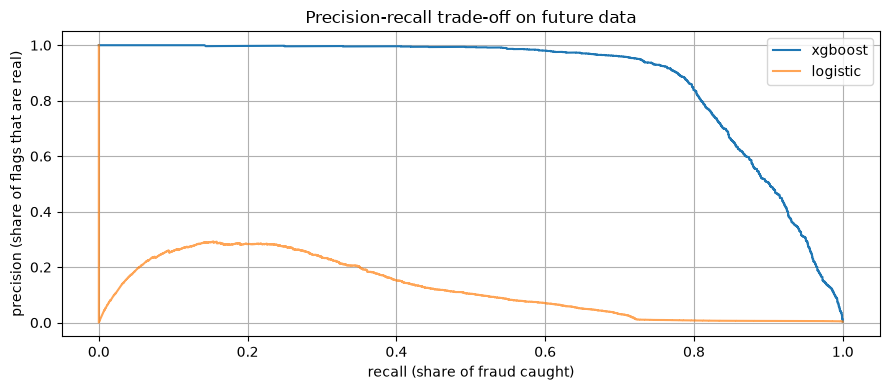

In [9]:
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve)

y_test = y[~train].values
print(f'Null model (never flag anything) accuracy: {(y_test == 0).mean():.3%}  <- useless but impressive-looking')
print(f'PR-AUC  logistic: {average_precision_score(y_test, p_logit):.3f}')
print(f'PR-AUC  xgboost : {average_precision_score(y_test, p_xgb):.3f}   (1.0 = perfect, {y_test.mean():.4f} = random)')

prec, rec, thr = precision_recall_curve(y_test, p_xgb)
plt.plot(rec, prec, label='xgboost')
prec_l, rec_l, _ = precision_recall_curve(y_test, p_logit)
plt.plot(rec_l, prec_l, label='logistic', alpha=0.7)
plt.xlabel('recall (share of fraud caught)')
plt.ylabel('precision (share of flags that are real)')
plt.title('Precision-recall trade-off on future data')
plt.legend(); plt.tight_layout(); plt.show()

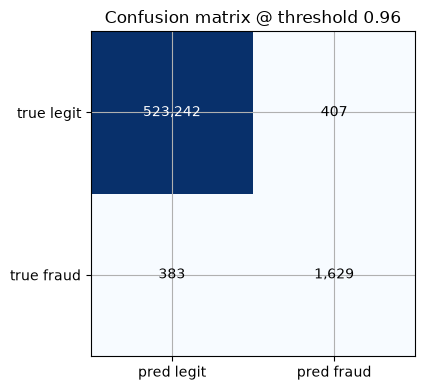

              precision    recall  f1-score   support

           0      0.999     0.999     0.999    523649
           1      0.800     0.810     0.805      2012

    accuracy                          0.998    525661
   macro avg      0.900     0.904     0.902    525661
weighted avg      0.999     0.998     0.999    525661

At this threshold: catches 81.0% of all fraud, 80.0% of flags are real fraud, and false alarms bother only 7.8 per 10,000 legitimate transactions.


In [10]:
# Business threshold: demand at least 80% precision (4 of 5 flags real),
# then take all the recall available at that price.
ok = prec[:-1] >= 0.80
t = thr[ok][np.argmax(rec[:-1][ok])]
y_hat = (p_xgb >= t).astype(int)

cm = confusion_matrix(y_test, y_hat)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center',
            color='white' if v > cm.max() / 2 else 'black')
ax.set_xticks([0, 1], ['pred legit', 'pred fraud'])
ax.set_yticks([0, 1], ['true legit', 'true fraud'])
ax.set_title(f'Confusion matrix @ threshold {t:.2f}')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(classification_report(y_test, y_hat, digits=3))
print(f'At this threshold: catches {tp / (tp + fn):.1%} of all fraud, '
      f'{tp / (tp + fp):.1%} of flags are real fraud, '
      f'and false alarms bother only {fp / (tn + fp) * 1e4:.1f} per 10,000 legitimate transactions.')

## Findings

1. **Fraud is a needle-in-haystack problem** - 0.52% of 1.85M transactions -
   so a model that never flags anything scores 99.5% accuracy while catching
   zero fraud. Precision/recall is the only honest lens.
2. **Fraud has a schedule and a wallet** - night transactions (22:00-03:59)
   run a **16.7x** higher fraud rate than daytime, online shopping is the
   riskiest category, and the median fraudulent charge ($390) is 8x the
   median legitimate one ($48).
3. **The distance feature was a null result.** Customer-to-merchant distance
   was hypothesized as the star signal (stolen cards used far from home) -
   the data said no: median distance is ~78 km for fraud and legit alike.
   Tested, rejected, and kept here as a documented negative finding - that
   is what honest feature engineering looks like.
4. **XGBoost decisively beats the linear baseline on future data** - PR-AUC
   **0.881** vs 0.120 (random ≈ 0.004), trained on 2019-mid-2020 and tested
   on the unseen second half of 2020. At an 80%-precision operating point it
   **catches 81% of all fraud while false-alarming only 7.8 per 10,000
   legitimate transactions.**